In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    fit_argon_lj_scale,
    query_argon_scaling_states,
)

MD_REPO = Path.home() / "MDsims"
ARGON_DIRECTORY = MD_REPO / "Argon"
DATA_DIRECTORY = ARGON_DIRECTORY / "data"
PLOT_DIRECTORY = ARGON_DIRECTORY / "plots"

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PLOT_DIRECTORY.mkdir(parents=True, exist_ok=True)

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)

print("Database:", paths.database)
print("Output data:", DATA_DIRECTORY)
print("Output plots:", PLOT_DIRECTORY)

Database: /exp/e961/data/MDsims-data/pnichols/SQL/mdsims.sqlite3
Output data: /home/pnichols/MDsims/Argon/data
Output plots: /home/pnichols/MDsims/Argon/plots


In [4]:
states = query_argon_scaling_states(database)

columns = [
    "Run_ID",
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

print("Selected states:", len(states))
print("Temperatures:", sorted(states["Therm_kT"].unique()))

states[columns].sort_values(
    ["Therm_kT", "Run_ID"]
).reset_index(drop=True);

Selected states: 44
Temperatures: [np.float64(0.86), np.float64(0.88), np.float64(0.9), np.float64(0.92), np.float64(0.94), np.float64(0.96), np.float64(0.98), np.float64(1.0)]


Argon table: /home/pnichols/MDsims/Tech Note/Argon Like/argon_saturation_clean.csv
Argon rows: 551


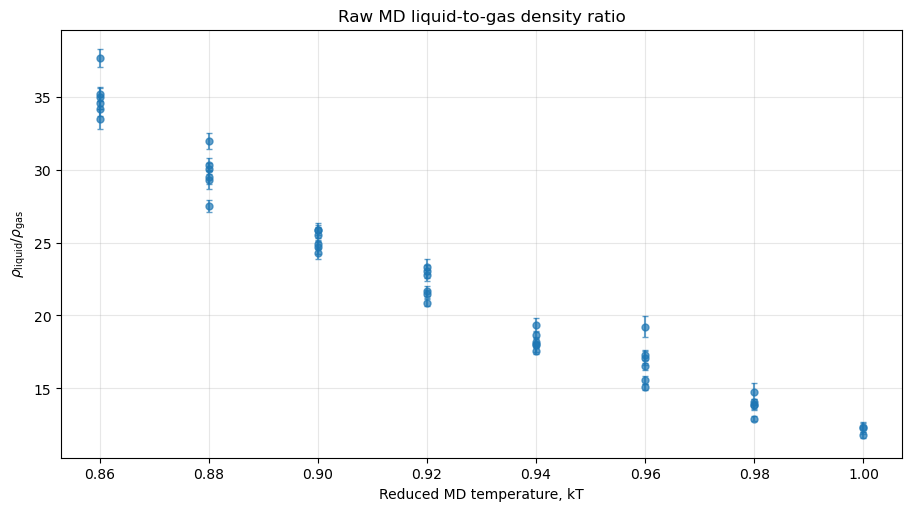

Fitted epsilon/kB: 128.5995507884122 +/- 0.04210981133938457 K
Temperature reduced chi2: 7.4093708866611285


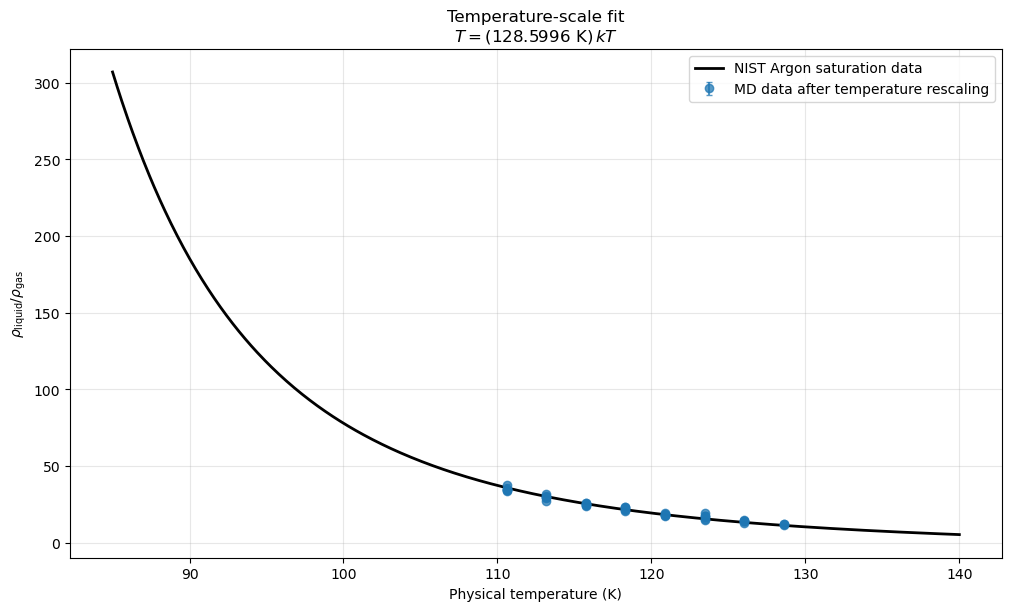

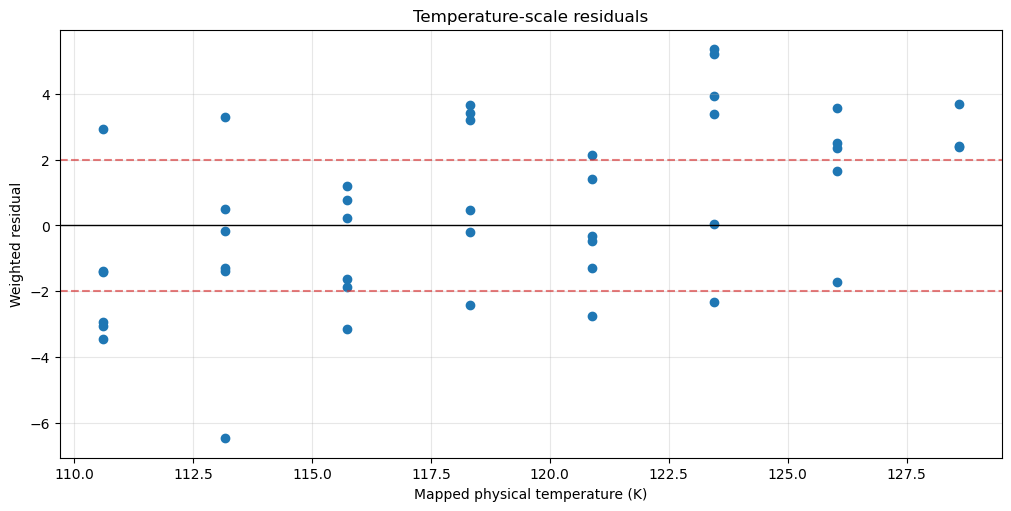

In [8]:
from md_Helpers.argon_scaling import default_argon_saturation_path

argon_path = default_argon_saturation_path()
argon = pd.read_csv(argon_path)

argon["density_ratio"] = (
    argon["density_liquid_mol_L"]
    / argon["density_vapor_mol_L"]
)

print("Argon table:", argon_path)
print("Argon rows:", len(argon))

argon[[
    "temperature_K",
    "density_liquid_mol_L",
    "density_vapor_mol_L",
    "density_ratio",
]]

ratio_raw = states[[
    "Run_ID",
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]].copy()

ratio_raw["density_ratio"] = (
    ratio_raw["rho_liquid"] / ratio_raw["rho_gas"]
)

ratio_raw["density_ratio_unc"] = (
    ratio_raw["density_ratio"]
    * np.sqrt(
        (
            ratio_raw["rho_liquid_unc"]
            / ratio_raw["rho_liquid"]
        ) ** 2
        + (
            ratio_raw["rho_gas_unc"]
            / ratio_raw["rho_gas"]
        ) ** 2
    )
)

ratio_raw = ratio_raw.sort_values(
    ["Therm_kT", "Run_ID"]
).reset_index(drop=True)

fig, axis = plt.subplots(
    figsize=(9, 5),
    constrained_layout=True,
)

axis.errorbar(
    ratio_raw["Therm_kT"],
    ratio_raw["density_ratio"],
    yerr=ratio_raw["density_ratio_unc"],
    fmt="o",
    markersize=5,
    capsize=2,
    alpha=0.7,
)

axis.set(
    xlabel="Reduced MD temperature, kT",
    ylabel=r"$\rho_\mathrm{liquid}/\rho_\mathrm{gas}$",
    title="Raw MD liquid-to-gas density ratio",
)
axis.grid(alpha=0.3)

plt.show()


fit = fit_argon_lj_scale(states)
scale = fit.scale


print(
    "Fitted epsilon/kB:",
    scale.epsilon_over_kb_K,
    "+/-",
    scale.epsilon_over_kb_uncertainty_K,
    "K",
)

print(
    "Temperature reduced chi2:",
    fit.temperature_reduced_chi2,
)

temperature_fit_table = fit.ratio_data[[
    "Run_ID",
    "Therm_kT",
    "temperature_K",
    "rho_liquid_to_gas",
    "ratio_unc",
    "argon_ratio",
    "ratio_weighted_residual",
]].copy()

temperature_fit_table = temperature_fit_table.rename(columns={
    "rho_liquid_to_gas": "MD_density_ratio",
    "ratio_unc": "MD_density_ratio_unc",
    "argon_ratio": "Argon_density_ratio",
})

fig, axis = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True,
)

axis.plot(
    argon["temperature_K"],
    argon["density_ratio"],
    color="black",
    linewidth=2,
    label="NIST Argon saturation data",
)

axis.errorbar(
    temperature_fit_table["temperature_K"],
    temperature_fit_table["MD_density_ratio"],
    yerr=temperature_fit_table["MD_density_ratio_unc"],
    fmt="o",
    markersize=6,
    capsize=2,
    color="tab:blue",
    alpha=0.75,
    label="MD data after temperature rescaling",
)

axis.set(
    xlabel="Physical temperature (K)",
    ylabel=r"$\rho_\mathrm{liquid}/\rho_\mathrm{gas}$",
    title=(
        "Temperature-scale fit\n"
        rf"$T = ({scale.epsilon_over_kb_K:.4f}\ \mathrm{{K}})\,kT$"
    ),
)
axis.legend()
axis.grid(alpha=0.3)

plt.show()



fig, axis = plt.subplots(
    figsize=(10, 5),
    constrained_layout=True,
)

axis.axhline(0, color="black", linewidth=1)
axis.axhline(2, color="tab:red", linestyle="--", alpha=0.6)
axis.axhline(-2, color="tab:red", linestyle="--", alpha=0.6)

axis.scatter(
    temperature_fit_table["temperature_K"],
    temperature_fit_table["ratio_weighted_residual"],
    color="tab:blue",
)

axis.set(
    xlabel="Mapped physical temperature (K)",
    ylabel="Weighted residual",
    title="Temperature-scale residuals",
)
axis.grid(alpha=0.3)

plt.show()

In [23]:
replicate_summary = (
    states.groupby("Therm_kT")
    .agg(
        runs=("Run_ID", "count"),
        liquid_mean=("rho_liquid", "mean"),
        liquid_std=("rho_liquid", "std"),
        mean_liquid_reported_unc=("rho_liquid_unc", "mean"),
        gas_mean=("rho_gas", "mean"),
        gas_std=("rho_gas", "std"),
        mean_gas_reported_unc=("rho_gas_unc", "mean"),
    )
    .reset_index()
)

replicate_summary

,Therm_kT,runs,liquid_mean,liquid_std,mean_liquid_reported_unc,gas_mean,gas_std,mean_gas_reported_unc
0,0.86,6,0.714539,0.001333,0.000362,0.020444,0.000807,0.000329
1,0.88,6,0.701366,0.001479,0.000368,0.023607,0.001135,0.000376
2,0.9,6,0.686942,0.001591,0.000381,0.027306,0.000704,0.000452
3,0.92,6,0.673849,0.002039,0.000381,0.030398,0.001377,0.000496
4,0.94,6,0.657763,0.002423,0.000394,0.035978,0.00128,0.000669
5,0.96,6,0.640033,0.003624,0.000406,0.038347,0.003399,0.000802
6,0.98,5,0.621431,0.004398,0.00043,0.044827,0.002331,0.001042
7,1.0,3,0.602114,0.001707,0.000474,0.049634,0.001287,0.00126


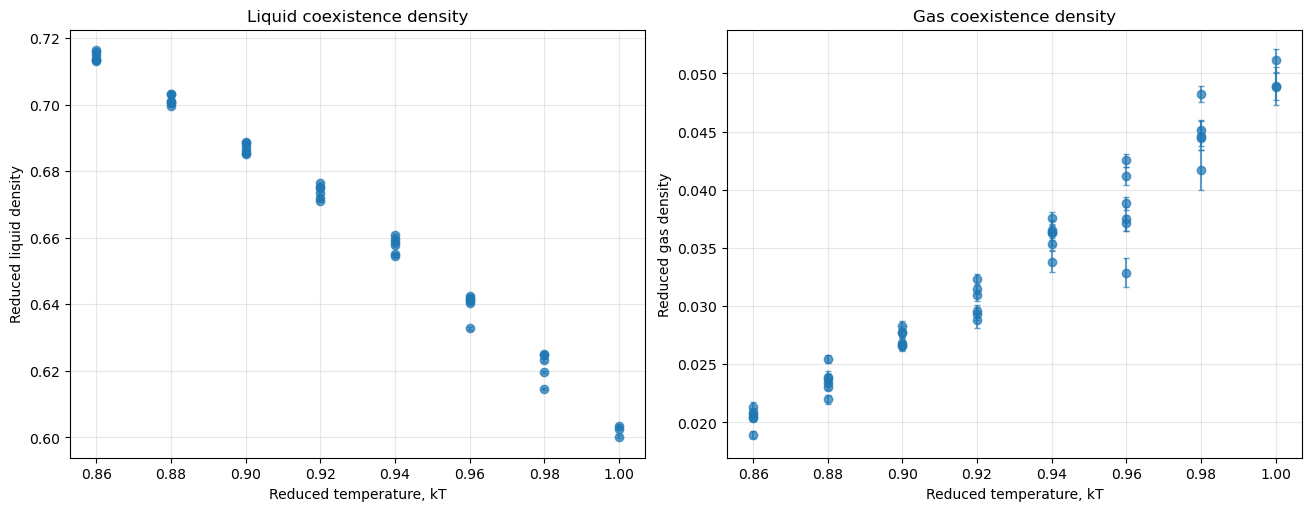

In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)

axes[0].errorbar(
    states["Therm_kT"],
    states["rho_liquid"],
    yerr=states["rho_liquid_unc"],
    fmt="o",
    capsize=2,
    alpha=0.7,
)
axes[0].set(
    xlabel="Reduced temperature, kT",
    ylabel="Reduced liquid density",
    title="Liquid coexistence density",
)
axes[0].grid(alpha=0.3)

axes[1].errorbar(
    states["Therm_kT"],
    states["rho_gas"],
    yerr=states["rho_gas_unc"],
    fmt="o",
    capsize=2,
    alpha=0.7,
)
axes[1].set(
    xlabel="Reduced temperature, kT",
    ylabel="Reduced gas density",
    title="Gas coexistence density",
)
axes[1].grid(alpha=0.3)

plt.show()

In [6]:
fit = fit_argon_lj_scale(states)
scale = fit.scale

scale_summary = scale.summary()

for name, value in scale_summary.items():
    print(f"{name}: {value}")

print()
print("Temperature reduced chi2:", fit.temperature_reduced_chi2)
print("Density reduced chi2:", fit.density_reduced_chi2)

epsilon_over_kB_K: 128.5995507884122
epsilon_over_kB_uncertainty_K: 0.04210981133938457
epsilon_J: 1.775508411964705e-21
epsilon_eV: 0.011081851865059125
sigma_nm: 0.33585470206734763
sigma_uncertainty_nm: 9.749997282766784e-06
mass_u: 39.948
mass_kg: 6.63352146325368e-26
time_ps: 2.0528732475325384
pressure_bar: 468.6713819873131
density_mol_L: 43.83235439561305
velocity_m_s: 163.60225964804692
force_N: 5.286537306268438e-12

Temperature reduced chi2: 7.4093708866611285
Density reduced chi2: 173.3929896388853


In [7]:
if fit.temperature_reduced_chi2 > 2:
    print(
        "WARNING: The temperature mapping does not describe the data "
        "within the reported uncertainties."
    )

if fit.density_reduced_chi2 > 2:
    print(
        "WARNING: The density mapping does not describe the data "
        "within the reported uncertainties."
    )

In [8]:
ratio_columns = [
    "Run_ID",
    "Therm_kT",
    "temperature_K",
    "rho_liquid_to_gas",
    "ratio_unc",
    "argon_ratio",
    "ratio_weighted_residual",
]

fit.ratio_data[ratio_columns]

,Run_ID,Therm_kT,temperature_K,rho_liquid_to_gas,ratio_unc,argon_ratio,ratio_weighted_residual
0,20260915173225,0.86,110.595614,34.560153,0.434525,35.838444,-2.941808
1,20260915173427,0.86,110.595614,35.184482,0.470216,35.838444,-1.390768
2,20260915173627,0.86,110.595614,34.188085,0.540064,35.838444,-3.055860
3,20260915173827,0.86,110.595614,37.642945,0.617467,35.838444,2.922424
4,20260915174027,0.86,110.595614,34.968743,0.612418,35.838444,-1.420110
5,20260915174228,0.86,110.595614,33.445799,0.693565,35.838444,-3.449775
6,20260915174430,0.88,113.167605,30.059536,0.371478,30.122152,-0.168560
7,20260915174630,0.88,113.167605,30.339878,0.432118,30.122152,0.503857
8,20260915174829,0.88,113.167605,27.479234,0.408437,30.122152,-6.470817
9,20260915175032,0.88,113.167605,29.501239,0.482757,30.122152,-1.286183


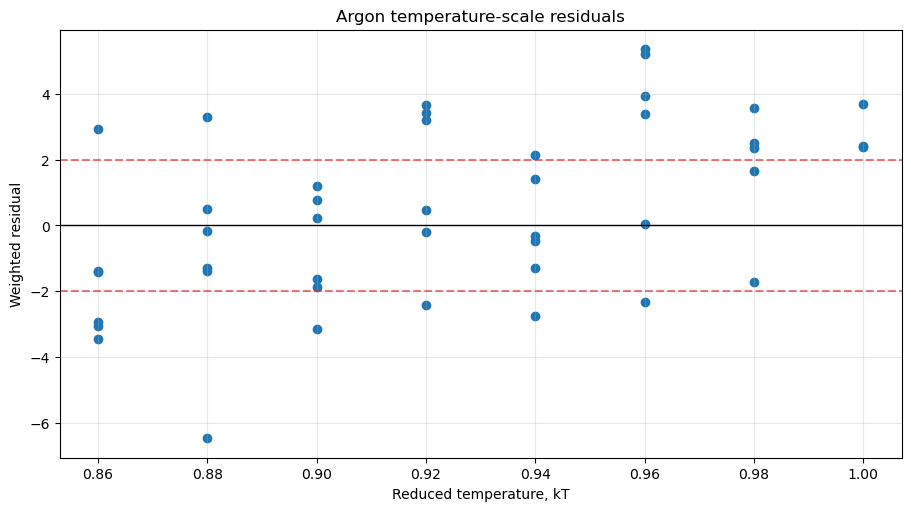

In [9]:
fig, axis = plt.subplots(
    figsize=(9, 5),
    constrained_layout=True,
)

axis.axhline(0, color="black", linewidth=1)
axis.axhline(2, color="tab:red", linestyle="--", alpha=0.6)
axis.axhline(-2, color="tab:red", linestyle="--", alpha=0.6)

axis.scatter(
    fit.ratio_data["Therm_kT"],
    fit.ratio_data["ratio_weighted_residual"],
)

axis.set(
    xlabel="Reduced temperature, kT",
    ylabel="Weighted residual",
    title="Argon temperature-scale residuals",
)
axis.grid(alpha=0.3)

plt.show()

In [10]:
fit.density_data[[
    "phase",
    "rho_sim",
    "rho_sim_unc",
    "rho_argon",
    "relative_unc",
    "weighted_log_residual",
]]

,phase,rho_sim,rho_sim_unc,rho_argon,relative_unc,weighted_log_residual
0,Liquid,0.715765,0.000391,30.997833,0.000547,22.0453
1,Liquid,0.716306,0.000365,30.997833,0.00051,25.108233
2,Liquid,0.713656,0.000371,30.997833,0.00052,17.512666
3,Liquid,0.71347,0.000351,30.997833,0.000492,17.986179
4,Liquid,0.714967,0.000346,30.997833,0.000484,22.598761
...,...,...,...,...,...,...
83,Vapor,0.044646,0.001254,2.095614,0.028095,-2.436898
84,Vapor,0.04167,0.001713,2.095614,0.041111,-3.343248
85,Vapor,0.051119,0.000969,2.405642,0.018964,-3.745911
86,Vapor,0.048858,0.001142,2.405642,0.023371,-4.975867


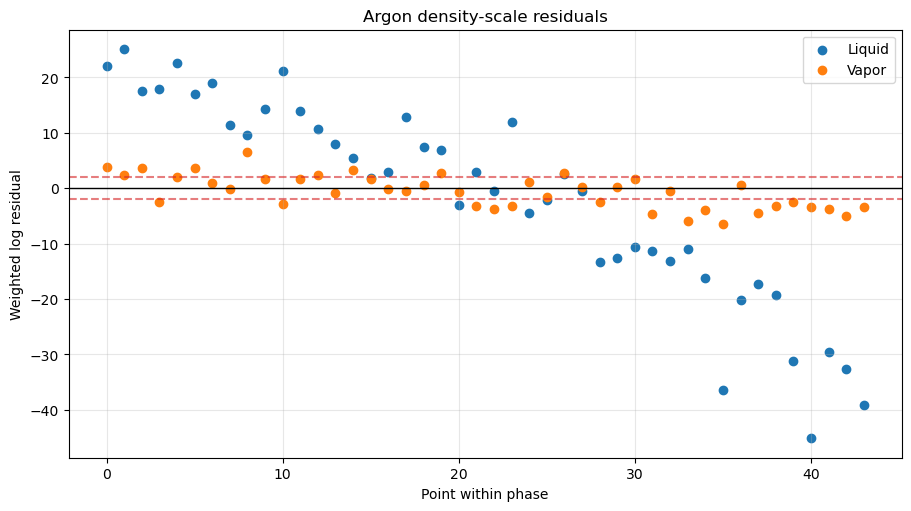

In [11]:
fig, axis = plt.subplots(
    figsize=(9, 5),
    constrained_layout=True,
)

axis.axhline(0, color="black", linewidth=1)
axis.axhline(2, color="tab:red", linestyle="--", alpha=0.6)
axis.axhline(-2, color="tab:red", linestyle="--", alpha=0.6)

for phase, group in fit.density_data.groupby("phase"):
    axis.scatter(
        range(len(group)),
        group["weighted_log_residual"],
        label=phase,
    )

axis.set(
    xlabel="Point within phase",
    ylabel="Weighted log residual",
    title="Argon density-scale residuals",
)
axis.legend()
axis.grid(alpha=0.3)

plt.show()

In [12]:
scale_record = {
    **{name: float(value) for name, value in scale_summary.items()},
    "temperature_chi2": float(fit.temperature_chi2),
    "temperature_dof": int(fit.temperature_dof),
    "temperature_reduced_chi2": float(
        fit.temperature_reduced_chi2
    ),
    "density_chi2": float(fit.density_chi2),
    "density_dof": int(fit.density_dof),
    "density_reduced_chi2": float(
        fit.density_reduced_chi2
    ),
    "number_of_selected_states": int(len(states)),
}

scale_path = DATA_DIRECTORY / "argon_lj_scale.json"
ratio_path = DATA_DIRECTORY / "argon_temperature_fit_points.csv"
density_path = DATA_DIRECTORY / "argon_density_fit_points.csv"
state_path = DATA_DIRECTORY / "argon_scaling_input_states.csv"

scale_path.write_text(
    json.dumps(scale_record, indent=2) + "\n"
)

fit.ratio_data.to_csv(ratio_path, index=False)
fit.density_data.to_csv(density_path, index=False)
states.to_csv(state_path, index=False)

print("Saved:", scale_path)
print("Saved:", ratio_path)
print("Saved:", density_path)
print("Saved:", state_path)

Saved: /home/pnichols/MDsims/Argon/data/argon_lj_scale.json
Saved: /home/pnichols/MDsims/Argon/data/argon_temperature_fit_points.csv
Saved: /home/pnichols/MDsims/Argon/data/argon_density_fit_points.csv
Saved: /home/pnichols/MDsims/Argon/data/argon_scaling_input_states.csv
